# Xenium Spatial Transcriptomics Analysis

10x Genomics Xenium (single-cell resolution) 종양 데이터에 대한 Niche/Neighborhood 분석 파이프라인.

파이프라인: QC → Annotation → Ligand-Receptor Interaction → Niche → Neighborhood

In [2]:
import sys
sys.path.append("..")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import spatialdata_io

from src import qc, annotation, lr_interaction, niche, neighborhood

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


## 0. 데이터 로드

Xenium 데이터 경로 지정.

이 서버는 메모리 여유가 크지 않으므로, morphology 이미지(~4.5GB)와 대용량 transcript parquet
로딩은 건너뛰고 세포 단위 발현 테이블(AnnData)만 읽어서 사용한다.

In [3]:
# Xenium 원본 데이터 디렉토리 (10x Xenium Onboard Analysis 출력 폴더)
DATA_DIR = "/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/Xenium_V1_humanLung_Cancer_FFPE"

In [4]:
# 메모리 부담이 큰 요소(형태학 이미지, transcript, 폴리곤/라벨 등)는 모두 끄고
# 세포 x 유전자 발현 테이블(AnnData)만 로드한다.
sdata = spatialdata_io.xenium(
    DATA_DIR,
    cells_boundaries=False,    # 세포 경계 폴리곤 - 이번 분석엔 불필요
    nucleus_boundaries=False,  # 핵 경계 폴리곤 - 이번 분석엔 불필요
    cells_labels=False,        # 세포 라벨 래스터 - 이번 분석엔 불필요
    nucleus_labels=False,      # 핵 라벨 래스터 - 이번 분석엔 불필요
    transcripts=False,         # transcript parquet(수억 행) - 메모리 절약을 위해 스킵
    morphology_mip=False,      # morphology MIP 이미지 - 메모리 절약을 위해 스킵
    morphology_focus=False,    # morphology focus 이미지(~4.5GB) - 메모리 절약을 위해 스킵
    aligned_images=False,      # 정합된 H&E/IF 이미지 - 이번 분석엔 불필요
    cells_table=True,          # 세포 단위 발현 테이블(AnnData) - 필요
    gex_only=False,            # negative control probe/codeword를 var에서 제외하지 않고 유지
)
print(sdata.shapes)

{}


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


In [5]:
# SpatialData 객체에서 세포 단위 발현 테이블(AnnData)만 꺼내서 이후 QC/분석에 사용
adata = sdata.tables["table"]
print(adata.shape)

(162254, 541)


In [6]:
print(adata.var.columns.tolist())

['gene_ids', 'feature_types', 'genome']


In [7]:

print(adata.var["feature_types"].value_counts())

feature_types
Gene Expression              377
Unassigned Codeword          103
Negative Control Codeword     41
Negative Control Probe        20
Name: count, dtype: int64


In [8]:
# feature_types 분포 확인 후, Gene Expression만 남기기
adata = adata[:, adata.var["feature_types"] == "Gene Expression"].copy()
print(adata.shape)   # (162254, 377) 기대

(162254, 377)


## 1. Quality Control

In [9]:
# Xenium feature matrix에는 실제 유전자 외에 QC용 대조군(negative control) 피처가 함께 들어있다.
#  - Negative Control Probe: 특정 유전자에 매칭되지 않는 프로브. 프로브 자체의 비특이적 배경 신호 추정용.
#  - Negative Control Codeword: 존재하지 않는 코드워드. 광학 디코딩 과정의 배경 신호(오검출) 추정용.
#  - Unassigned Codeword: 패널의 어떤 유전자에도 할당되지 않은 코드워드. 디코딩 노이즈 추정용.
# 이 정보는 h5 로딩 시 gex_only=False로 유지했기 때문에 adata.var["feature_types"]에 남아 있다.
adata.var["is_gene"] = (adata.var["feature_types"] == "Gene Expression").values
adata.var["is_neg_control_probe"] = (adata.var["feature_types"] == "Negative Control Probe").values
adata.var["is_neg_control_codeword"] = (adata.var["feature_types"] == "Negative Control Codeword").values
adata.var["is_unassigned_codeword"] = (adata.var["feature_types"] == "Unassigned Codeword").values

# 이 패널/버전에 실제로 존재하는 대조군 카테고리만 qc_vars로 전달 (없으면 0으로만 채워짐)
qc_vars = [
    col
    for col in ["is_neg_control_probe", "is_neg_control_codeword", "is_unassigned_codeword"]
    if adata.var[col].any()
]

# 세포별 total_counts, n_genes_by_counts 및 qc_vars별 total_counts_*, pct_counts_* 를 계산해 obs에 추가
sc.pp.calculate_qc_metrics(adata, qc_vars=qc_vars, percent_top=None, inplace=True)
adata.obs[["total_counts", "n_genes_by_counts"]].describe()

,total_counts,n_genes_by_counts
count,162254.000000,162254.000000
mean,56.593426,30.201826
std,42.422794,15.080533
min,0.000000,0.000000
25%,27.000000,19.000000
50%,46.000000,29.000000
75%,75.000000,40.000000
max,549.000000,119.000000


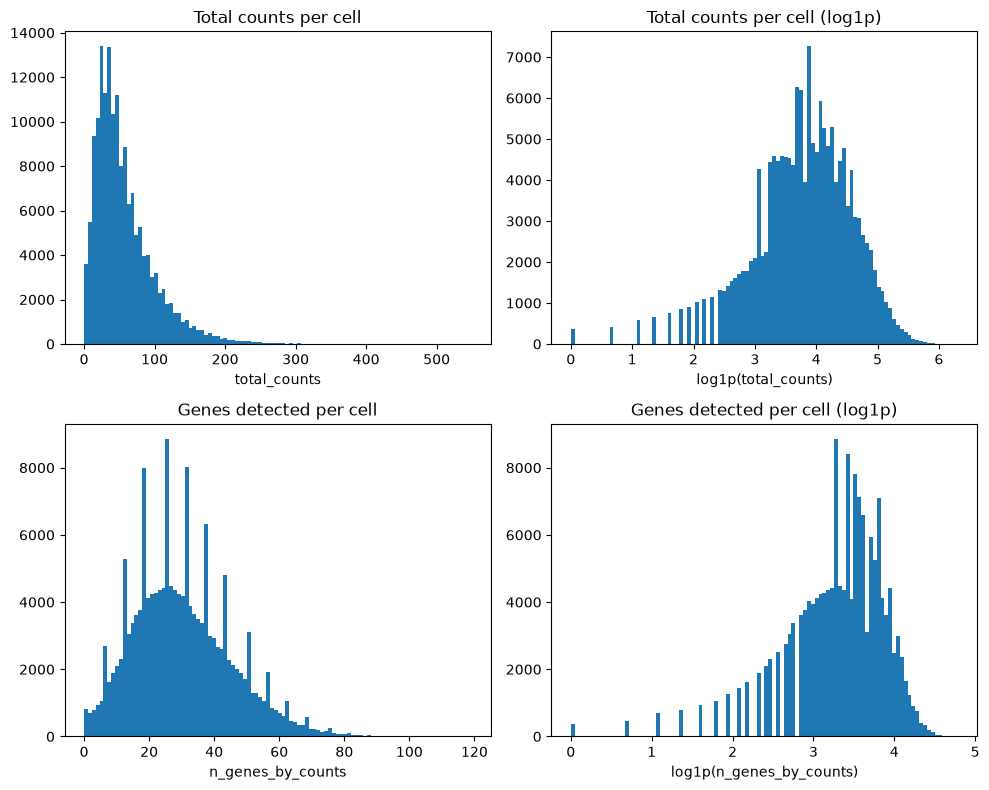

In [10]:
# 세포별 total_counts, n_genes_by_counts 분포 시각화 (선형 스케일 + log1p 스케일)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(adata.obs["total_counts"], bins=100)
axes[0, 0].set_title("Total counts per cell")
axes[0, 0].set_xlabel("total_counts")

axes[0, 1].hist(np.log1p(adata.obs["total_counts"]), bins=100)
axes[0, 1].set_title("Total counts per cell (log1p)")
axes[0, 1].set_xlabel("log1p(total_counts)")

axes[1, 0].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1, 0].set_title("Genes detected per cell")
axes[1, 0].set_xlabel("n_genes_by_counts")

axes[1, 1].hist(np.log1p(adata.obs["n_genes_by_counts"]), bins=100)
axes[1, 1].set_title("Genes detected per cell (log1p)")
axes[1, 1].set_xlabel("log1p(n_genes_by_counts)")

fig.tight_layout()
plt.show()

In [11]:
# 컷오프(MIN_COUNTS, MIN_GENES) 결정에 참고할 분위수 확인
adata.obs[["total_counts", "n_genes_by_counts"]].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9])

,total_counts,n_genes_by_counts
0.01,3.0,3.0
0.05,10.0,8.0
0.10,15.0,12.0
0.25,27.0,19.0
0.50,46.0,29.0
0.75,75.0,40.0
0.90,112.0,51.0


In [12]:
# Negative control probe/codeword 비율 계산 및 출력 (해당 카테고리가 존재하는 경우만).
# - 셀당 평균/중앙값 비율: calculate_qc_metrics가 만든 pct_counts_<flag> (셀별 %) 기준
# - 데이터셋 전체 비율: 전체 카운트 합산 기준 (var 단위 total_counts 합)
if qc_vars:
    total_counts_all = adata.var["total_counts"].sum()
    for col in qc_vars:
        pct_col = f"pct_counts_{col}"
        ctrl_total = adata.var.loc[adata.var[col], "total_counts"].sum()
        dataset_ratio = 100 * ctrl_total / total_counts_all
        print(
            f"[{col}] 셀당 평균 비율: {adata.obs[pct_col].mean():.4f}%, "
            f"중앙값: {adata.obs[pct_col].median():.4f}%, "
            f"데이터셋 전체 비율: {dataset_ratio:.4f}%"
        )
else:
    print("이 데이터에는 negative control probe/codeword 카테고리가 없습니다.")

이 데이터에는 negative control probe/codeword 카테고리가 없습니다.


### 저품질 세포 필터링

In [13]:
# 저품질 세포 필터링 컷오프.
# squidpy 공식 Xenium 튜토리얼
# (https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html)은
# sc.pp.filter_cells(adata, min_counts=10) 를 기본 컷오프로 사용한다.
# Xenium은 타깃 패널(이 데이터는 유전자 377개)만 측정하므로 scRNA-seq 대비
# 세포당 총 카운트/검출 유전자 수 자체가 훨씬 낮게 나오는 것이 정상이며,
# 그만큼 컷오프도 낮게 잡는 것이 튜토리얼의 기본 가정이다.
# 위 히스토그램/분위수 결과를 보고 이 값이 이 데이터 분포에 비해 너무 관대하거나
# 너무 엄격하면 아래 두 값을 조정한다.
MIN_COUNTS = 10   # 원 데이터셋 처리 기준: >10 transcripts
MIN_GENES = 5     # 원 데이터셋 처리 기준: >5 unique genes

n_cells_before = adata.n_obs
cell_mask = (adata.obs["total_counts"] >= MIN_COUNTS) & (adata.obs["n_genes_by_counts"] >= MIN_GENES)
adata = adata[cell_mask].copy()

print(f"필터링 전: {n_cells_before}개 세포")
print(f"필터링 후: {adata.n_obs}개 세포 ({adata.n_obs / n_cells_before:.1%} 유지)")

필터링 전: 162254개 세포
필터링 후: 154469개 세포 (95.2% 유지)


### Normalization & log1p

In [14]:
# 원본 카운트 보관 (일부 하위 분석이 raw count를 요구할 수 있음)
adata.layers["counts"] = adata.X.copy()

In [15]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
print(adata)

AnnData object with n_obs × n_vars = 154469 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'is_gene', 'is_neg_control_probe', 'is_neg_control_codeword', 'is_unassigned_codeword', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs', 'log1p'
    obsm: 'spatial'
    layers: 'counts'


In [16]:
print(adata.X.max()) # 로그 변환 후라 원래 549 → 훨씬 작은 값이어야 정상

3.3945084


### 2-1. Dimensionality Reduction & Clustering (PCA → Neighbors → Leiden → UMAP)

In [17]:
# Xenium은 377개 유전자로 구성된 타깃 패널이므로(전장 transcriptome이 아님) HVG 선택 없이
# 전체 유전자를 사용해 PCA를 수행한다. n_comps는 관례적인 50과 (유전자 수 - 1) 중 작은 값 사용.
N_COMPS = min(50, adata.n_vars - 1)
sc.pp.pca(adata, n_comps=N_COMPS)
print(f"PCA 완료: n_comps={N_COMPS}")
# 예상 소요 시간: 154,469 세포 x 377 유전자 규모에서는 수십 초 이내 (가벼운 연산)

PCA 완료: n_comps=50


In [18]:
# PCA 결과(50 PC) 기반 kNN 그래프 생성. 이후 Leiden 클러스터링과 UMAP의 입력이 된다.
# 예상 소요 시간: 154,469 세포 규모에서 약 2~5분 (서버 CPU/부하 상황에 따라 변동)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=N_COMPS)

In [19]:
# Leiden 클러스터링 resolution. 클러스터가 너무 세분화되면 낮추고(예: 0.5~0.8),
# 너무 뭉뚱그려지면 높인다(예: 1.2~1.5). 필요 시 이 값만 조정 후 재실행하면 됨.
LEIDEN_RES = 1.0

# flavor="igraph", n_iterations=2, directed=False는 scanpy가 권장하는 최신 설정
# (기존 기본값인 flavor="leidenalg"는 향후 deprecated 예정).
# 예상 소요 시간: 154,469 세포 규모에서 약 3~8분 (resolution·그래프 밀도에 따라 변동)
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RES,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
print(adata.obs["leiden"].value_counts())

leiden
9     29623
7     25359
8     19408
0     18198
5     16332
2     11557
10    11123
6      8334
3      4856
13     2870
12     2368
11     1968
1      1369
4      1104
Name: count, dtype: int64


In [20]:
# UMAP 임베딩. neighbors 그래프가 이미 계산되어 있어야 함.
# 예상 소요 시간: 154,469 세포 규모에서 약 3~7분 (이 단계가 지금까지 중 가장 오래 걸릴 수 있음)
sc.tl.umap(adata)

### 2-2. 시각화: UMAP + 공간 분포

In [23]:
adata.obs["leiden"].nunique()

14

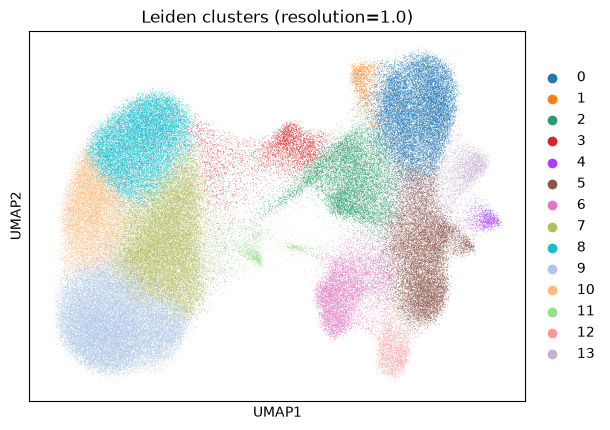

In [21]:
# UMAP에 Leiden 클러스터를 색칠하여 클러스터 분리도를 확인
sc.pl.umap(adata, color="leiden", title=f"Leiden clusters (resolution={LEIDEN_RES})")

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


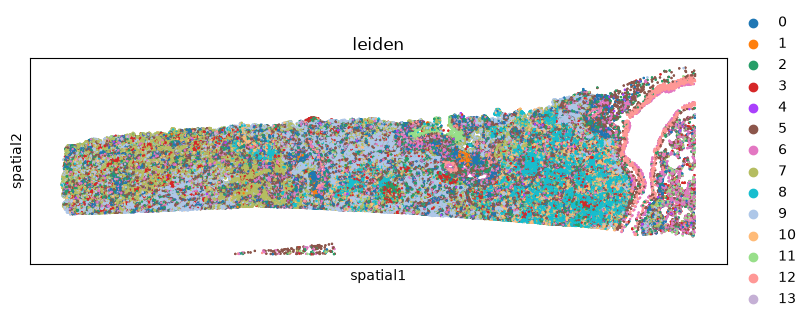

In [24]:
# 실제 공간 좌표(adata.obsm["spatial"])에 동일한 Leiden 클러스터를 뿌려 공간 분포 확인.
# morphology 이미지를 로드하지 않았으므로 img=False, 세포 수가 많아 shape=None(점 표시)과
# 작은 size로 렌더링 부담을 줄인다.
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    shape=None,
    size=2,
    img=False,
    figsize=(8, 8),
)

## 2. Cell-Type Annotation

In [ ]:
# marker_dict = {...}
# adata = annotation.run_leiden_clustering(adata)
# adata = annotation.score_marker_genes(adata, marker_dict)
# adata = annotation.annotate_cell_types(adata, marker_dict)

## 3. Ligand-Receptor Interaction

In [ ]:
# ligrec_result = lr_interaction.run_ligrec(adata, cluster_key="cell_type")
# lr_summary = lr_interaction.summarize_lr_results(ligrec_result)

## 4. Niche Definition

In [ ]:
# composition_df = niche.compute_cell_type_composition(adata, cluster_key="cell_type")
# niche_labels = niche.define_niches(composition_df, n_niches=10)
# adata = niche.assign_niche_labels(adata, niche_labels)

## 5. Neighborhood Enrichment / Co-occurrence

In [ ]:
# adata = neighborhood.build_spatial_neighbors(adata, coord_type="generic")
# nhood_result = neighborhood.run_nhood_enrichment(adata, cluster_key="niche")
# co_occurrence_result = neighborhood.run_co_occurrence(adata, cluster_key="niche")